In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Cardata.csv')

# Display the first few rows
df.head()



,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
# Statistical summary of numerical columns
print("Summary Statistics:")
display(df.describe())

# Check for missing values and data types
print("\nDataset Info:")
df.info()


Summary Statistics:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


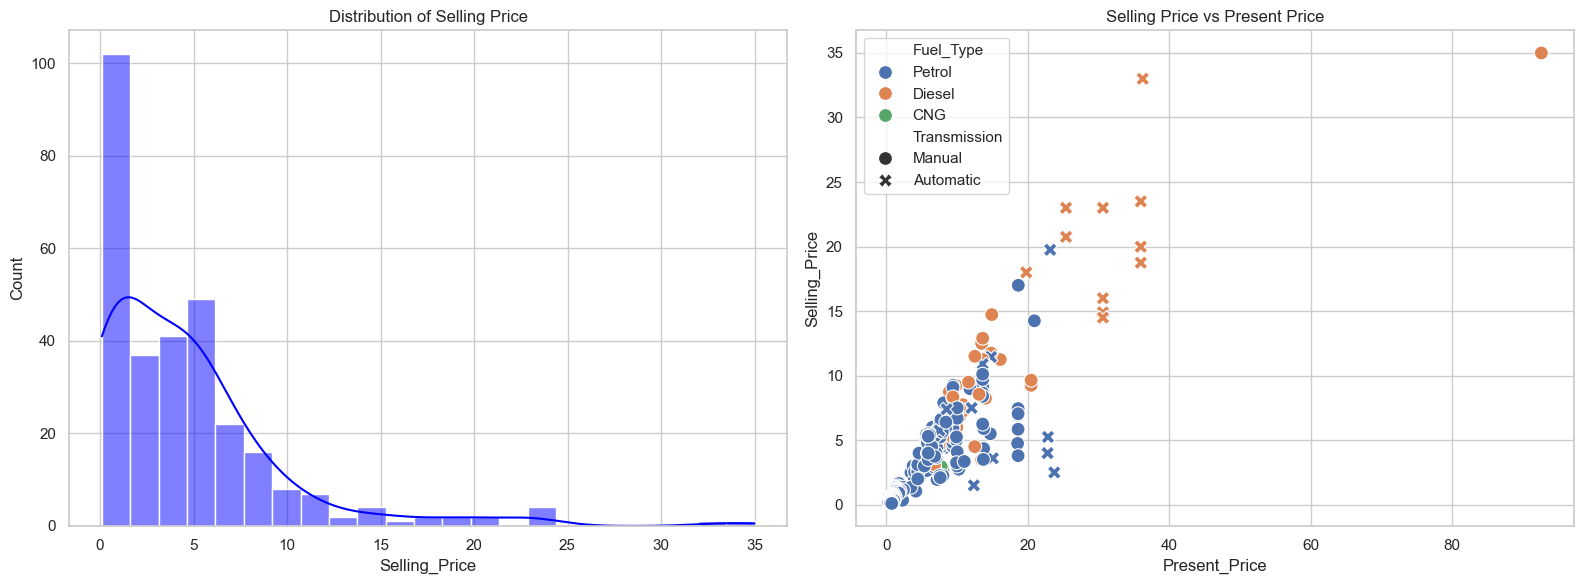

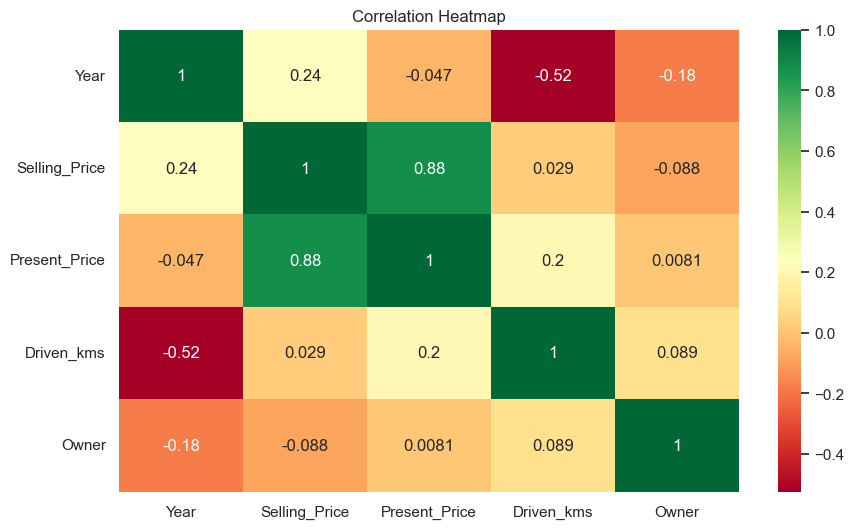

In [3]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with multiple plots
plt.figure(figsize=(16, 6))

# Plot 1: Distribution of Selling Price
plt.subplot(1, 2, 1)
sns.histplot(df['Selling_Price'], kde=True, color='blue')
plt.title('Distribution of Selling Price')

# Plot 2: Selling Price vs Present Price (Color coded by Fuel Type)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type', style='Transmission', s=100)
plt.title('Selling Price vs Present Price')

plt.tight_layout()
plt.show()

# Plot 3: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn')
plt.title('Correlation Heatmap')
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Feature Engineering: Convert Year to Age
current_year = 2024
df['Car_Age'] = current_year - df['Year']

# 2. Drop unnecessary columns
model_df = df.drop(['Car_Name', 'Year'], axis=1)

# 3. One-Hot Encoding for categorical variables
model_df = pd.get_dummies(model_df, drop_first=True)

# 4. Split data into X (features) and y (target)
X = model_df.drop('Selling_Price', axis=1)
y = model_df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize and train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model Training Complete.")


Model Training Complete.


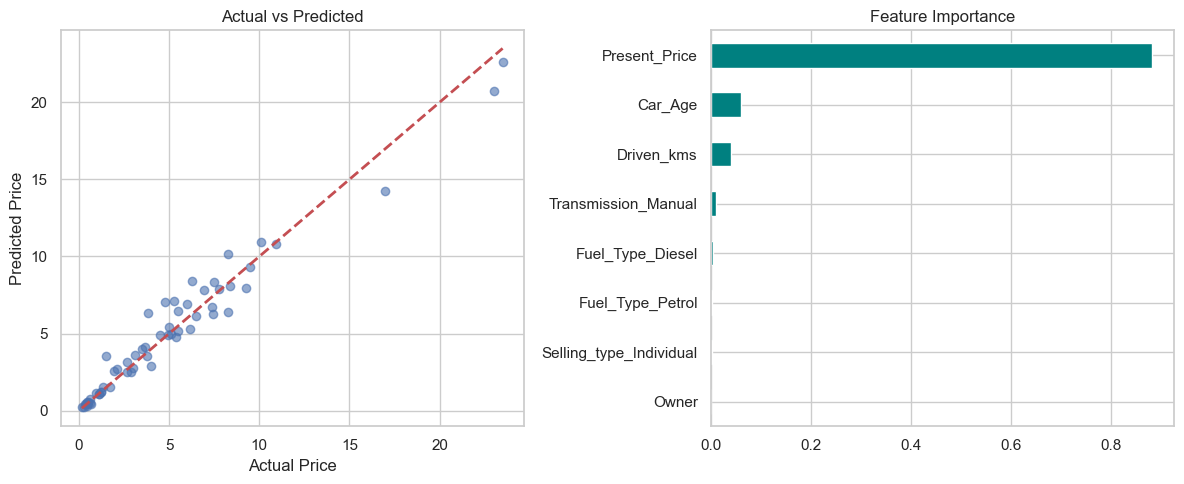

In [5]:
# Make predictions
predictions = rf_model.predict(X_test)

# Plot 1: Actual vs Predicted Prices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

# Plot 2: Feature Importance
plt.subplot(1, 2, 2)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance')

plt.tight_layout()
plt.show()


In [6]:
# Create a detailed comparison table
# We use the index of X_test to pull the original car names from the initial dataframe
test_indices = X_test.index
detailed_results = df.loc[test_indices].copy()

# Add the predicted prices to the dataframe
detailed_results['Predicted_Price'] = predictions.round(2)

# Select and organize columns for the final report
final_output = detailed_results[[
    'Car_Name', 'Year', 'Present_Price', 'Driven_kms', 
    'Fuel_Type', 'Selling_Price', 'Predicted_Price'
]]

# Rename Selling_Price to Actual_Price for clarity
final_output.rename(columns={'Selling_Price': 'Actual_Price'}, inplace=True)



# Display the first 10 results
print("Final Output: Car Details with Actual vs Predicted Price")
final_output.head(10)



Final Output: Car Details with Actual vs Predicted Price


C:\Users\Nehas\AppData\Local\Temp\ipykernel_9692\2549635210.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_output.rename(columns={'Selling_Price': 'Actual_Price'}, inplace=True)


,Car_Name,Year,Present_Price,Driven_kms,Fuel_Type,Actual_Price,Predicted_Price
177,Honda Activa 125,2016,0.57,24000,Petrol,0.35,0.44
289,city,2016,13.60,10980,Petrol,10.11,10.91
228,verna,2012,9.40,60000,Diesel,4.95,4.93
198,Bajaj Discover 125,2011,0.57,35000,Petrol,0.15,0.22
60,corolla altis,2013,18.61,40001,Petrol,6.95,7.80
9,ciaz,2015,8.92,42367,Diesel,7.45,6.25
118,Royal Enfield Classic 350,2015,1.47,26000,Petrol,1.10,1.11
154,Yamaha Fazer,2014,0.88,8000,Petrol,0.50,0.59
164,Hero Splender iSmart,2016,0.54,14000,Petrol,0.45,0.47
33,ertiga,2014,9.95,45000,Diesel,6.00,6.90


In [7]:
#testing with new data 
import pandas as pd

# 1. Define  new data in an array format
# Format: [Car_Name, Year, Present_Price, Driven_kms, Fuel_Type, Selling_type, Transmission, Owner]
new_cars_array = [
    ['maruti swift', 2017, 7.50, 15000, 'Petrol', 'Dealer', 'Manual', 0],
    ['hyundai verna', 2015, 12.00, 40000, 'Diesel', 'Dealer', 'Manual', 0],
    ['honda city', 2018, 15.00, 10000, 'Petrol', 'Dealer', 'Automatic', 0]
]

# 2. Convert array to DataFrame
columns = ['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
new_data = pd.DataFrame(new_cars_array, columns=columns)

# 3. Preprocess the new data to match training format
# Calculate Age
new_data['Car_Age'] = 2024 - new_data['Year']

# Prepare for prediction (Drop Name and Year, then One-Hot Encode)
predict_df = new_data.drop(['Car_Name', 'Year'], axis=1)
predict_df = pd.get_dummies(predict_df)

# Align columns with X_train (ensuring all dummy columns exist)
# This handles cases where 'CNG' or 'Individual' might be missing in the small test array
for col in X_train.columns:
    if col not in predict_df.columns:
        predict_df[col] = 0

# Ensure the column order is exactly the same as X_train
predict_df = predict_df[X_train.columns]

# 4. Make Predictions
new_predictions = rf_model.predict(predict_df)

# 5. Display Final Result
new_data['Predicted_Selling_Price'] = new_predictions.round(2)
new_data[['Car_Name', 'Year', 'Present_Price', 'Predicted_Selling_Price']]

,Car_Name,Year,Present_Price,Predicted_Selling_Price
0,maruti swift,2017,7.5,6.14
1,hyundai verna,2015,12.0,9.10
2,honda city,2018,15.0,14.90
